# Import Libraries

In [5]:
pip install -U scikit-learn

Note: you may need to restart the kernel to use updated packages.


In [14]:
import pandas as np
from sklearn.datasets import fetch_openml
import matplotlib.pyplot as plt

In [17]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.manifold import TSNE

import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Dense
from tensorflow.keras.optimizers import Adam

---

---

---

# 1- Data Loading:

In [18]:
mnist = fetch_openml('mnist_784', version=1, as_frame=False)
X = mnist.data.astype('float32') / 255.0   # Normalize
y = mnist.target.astype(int)


print(f'Shape: {X.shape} | Labels: {y.shape}')
print(f'Pixel range: [{X.min():.1f}, {X.max():.1f}]')

Shape: (70000, 784) | Labels: (70000,)
Pixel range: [0.0, 1.0]


checking

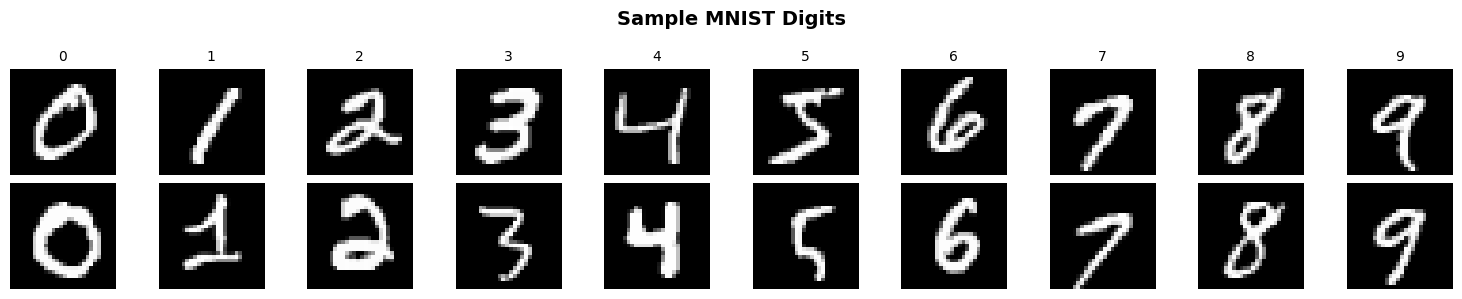

In [19]:
fig, axes = plt.subplots(2, 10, figsize=(15, 3))
fig.suptitle('Sample MNIST Digits', fontsize=14, fontweight='bold')

for digit in range(10):
    idxs = np.where(y == digit)[0]
    for row, idx in enumerate([idxs[0], idxs[5]]):
        axes[row, digit].imshow(X[idx].reshape(28, 28), cmap='gray')
        if row == 0:
            axes[row, digit].set_title(str(digit), fontsize=10)
        axes[row, digit].axis('off')

plt.tight_layout()
plt.show()

In [20]:
# Train/Test Split
# stratify=y يضمن توزيع متوازن لكل رقم في المجموعتين
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f'Train: {X_train.shape} | Test: {X_test.shape}')

Train: (56000, 784) | Test: (14000, 784)


# 2- AutoEncoder Architecture 

بسويه بهالطريقه :

Encoder : 

784 --> 256 --> 128 --> 32

Decoder :

32 --> 128 --> 256 --> 784

---

why?

هالطريقه تحرص ان كل طبقة تتعلم فيتشرز 

ليش 32 ؟

موازنه بين الضغط الكويس مع المعلومات المحفوظة 

ليش ريلو ؟

تجنبا للفنشنق 

ليش ادام؟

اذكى خيار

In [22]:
# ==================== Hyperparameters ====================
INPUT_DIM    = 784
LATENT_DIM   = 32    # جربت 8, 16, 64  و 32 كان الأفضل
LEARNING_RATE = 0.001
EPOCHS       = 20
BATCH_SIZE   = 256

# ==================== ENCODER ====================
encoder_input = Input(shape=(INPUT_DIM,), name='encoder_input')
x = Dense(256, activation='relu', name='enc_1')(encoder_input)
x = Dense(128, activation='relu', name='enc_2')(x)
latent = Dense(LATENT_DIM, activation='relu', name='latent_space')(x)

encoder = Model(encoder_input, latent, name='Encoder')

# ==================== DECODER ====================
decoder_input = Input(shape=(LATENT_DIM,), name='decoder_input')
x = Dense(128, activation='relu', name='dec_1')(decoder_input)
x = Dense(256, activation='relu', name='dec_2')(x)
# sigmoid في الأخير عشان القيم بين 0-1
decoder_output = Dense(INPUT_DIM, activation='sigmoid', name='dec_output')(x)

decoder = Model(decoder_input, decoder_output, name='Decoder')

# ==================== FULL AUTOENCODER ====================
ae_input = Input(shape=(INPUT_DIM,))
encoded  = encoder(ae_input)
decoded  = decoder(encoded)
autoencoder = Model(ae_input, decoded, name='Autoencoder')

autoencoder.compile(
    optimizer=Adam(learning_rate=LEARNING_RATE),
    loss='binary_crossentropy'
)

print('Autoencoder built!')
autoencoder.summary()

Autoencoder built!


Model: "Autoencoder"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Encoder (Functional)            │ (None, 32)             │       237,984 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Decoder (Functional)            │ (None, 784)            │       238,736 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 476,720 (1.82 MB)

 Trainable params: 476,720 (1.82 MB)

 Non-trainable params: 0 (0.00 B)

# 3-Training

In [23]:
history = autoencoder.fit(
    X_train, X_train,                      # Input = Target!
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    shuffle=True,
    validation_data=(X_test, X_test),
    verbose=1
)


Epoch 1/20
219/219 ━━━━━━━━━━━━━━━━━━━━ 5s 11ms/step - loss: 0.2316 - val_loss: 0.1500
Epoch 2/20
219/219 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - loss: 0.1365 - val_loss: 0.1258
Epoch 3/20
219/219 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - loss: 0.1194 - val_loss: 0.1139
Epoch 4/20
219/219 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - loss: 0.1108 - val_loss: 0.1078
Epoch 5/20
219/219 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - loss: 0.1056 - val_loss: 0.1038
Epoch 6/20
219/219 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - loss: 0.1022 - val_loss: 0.1011
Epoch 7/20
219/219 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - loss: 0.0998 - val_loss: 0.0991
Epoch 8/20
219/219 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - loss: 0.0980 - val_loss: 0.0974
Epoch 9/20
219/219 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - loss: 0.0964 - val_loss: 0.0961
Epoch 10/20
219/219 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - loss: 0.0951 - val_loss: 0.0950
Epoch 11/20
219/219 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - loss: 0.0940 - val_loss: 0.0940
Epoch 12/20
219/219 ━━━━━━━━━━━━━━━━━━━━ 2s 

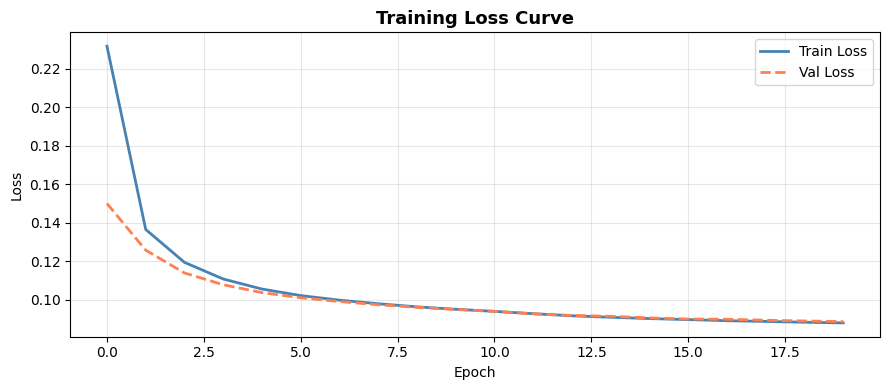

Final Train Loss: 0.0880
Final Val Loss:   0.0887


In [24]:
# نرسم منحنى الـ Loss
fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(history.history['loss'],     label='Train Loss', color='steelblue', lw=2)
ax.plot(history.history['val_loss'], label='Val Loss',   color='coral',     lw=2, ls='--')
ax.set_title('Training Loss Curve', fontsize=13, fontweight='bold')
ax.set_xlabel('Epoch'); ax.set_ylabel('Loss')
ax.legend(); ax.grid(True, alpha=0.3)
plt.tight_layout(); plt.show()

print(f'Final Train Loss: {history.history["loss"][-1]:.4f}')
print(f'Final Val Loss:   {history.history["val_loss"][-1]:.4f}')

# 4-Dimentionaly Reduction & Visualization

نقارن الأصلية بالمُعادة — كلما كانت أوضح = الموديل تعلم أفضل.

إذا كانت ضبابية جداً → `LATENT_DIM` صغير، جربي تزيدينه.

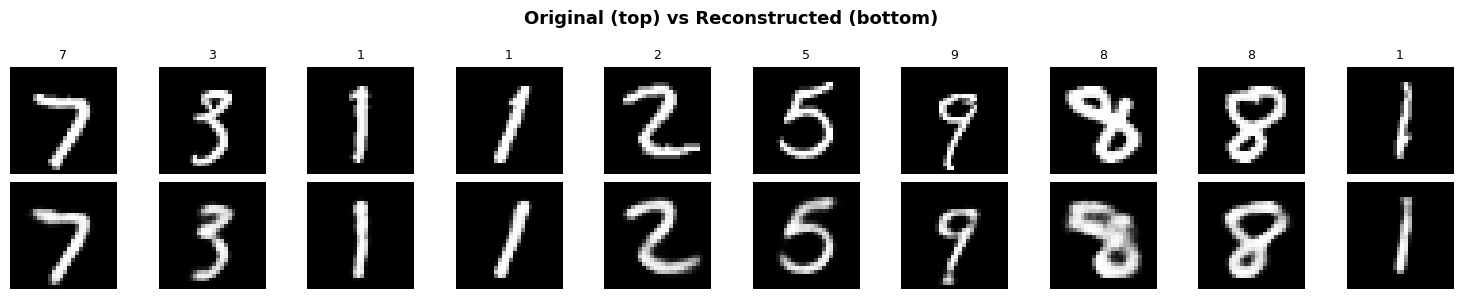

In [25]:
X_recon = autoencoder.predict(X_test, verbose=0)

n = 10
fig, axes = plt.subplots(2, n, figsize=(15, 3))
fig.suptitle('Original (top) vs Reconstructed (bottom)', fontsize=13, fontweight='bold')

for i in range(n):
    axes[0, i].imshow(X_test[i].reshape(28,28), cmap='gray')
    axes[0, i].set_title(f'{y_test[i]}', fontsize=9)
    axes[0, i].axis('off')
    axes[1, i].imshow(X_recon[i].reshape(28,28), cmap='gray')
    axes[1, i].axis('off')

plt.tight_layout()
plt.show()

# 5- Image Retrieval 

اول شي :

1. نختار صورة query من الـ test set
2. نرمزها بالـ Encoder → latent vector
3. نحسب Cosine Similarity مع كل الـ train set
4. نعرض أعلى 5 أكثر تشابهاً

**ليش Cosine Similarity؟**

- تقيس **الاتجاه** لا المسافة
- في الـ latent spaces: الاتجاه أهم من الحجم
- أرقام مكتوبة بأحجام مختلفة = نفس الاتجاه، مسافة Euclidean مختلفة
- القيمة بين -1 و1 — كلما قربت من 1 = أكثر تشابهاً

In [27]:
# نرمز الـ training set مرة واحدة ونخزنه
print(' Encoding training set...')
X_train_encoded = encoder.predict(X_train, verbose=0)
print(f'Train encoded: {X_train_encoded.shape}')

 Encoding training set...
Train encoded: (56000, 32)


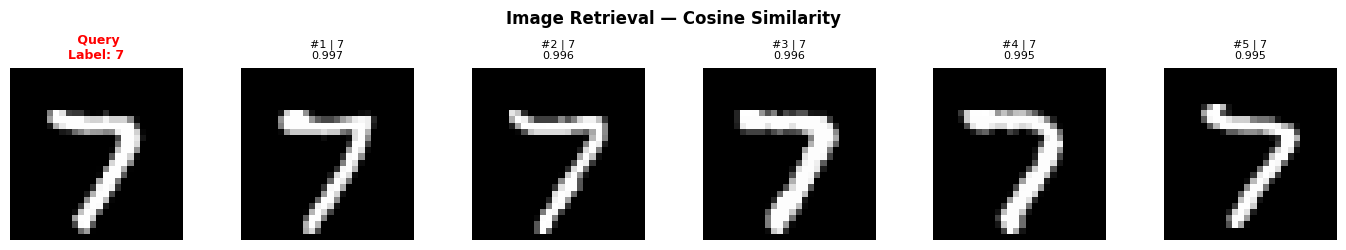

Query: 7 | Retrieved: [np.int64(7), np.int64(7), np.int64(7), np.int64(7), np.int64(7)]


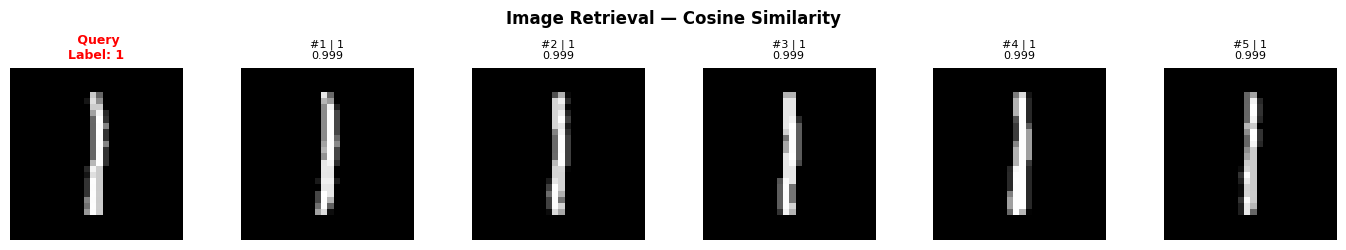

Query: 1 | Retrieved: [np.int64(1), np.int64(1), np.int64(1), np.int64(1), np.int64(1)]


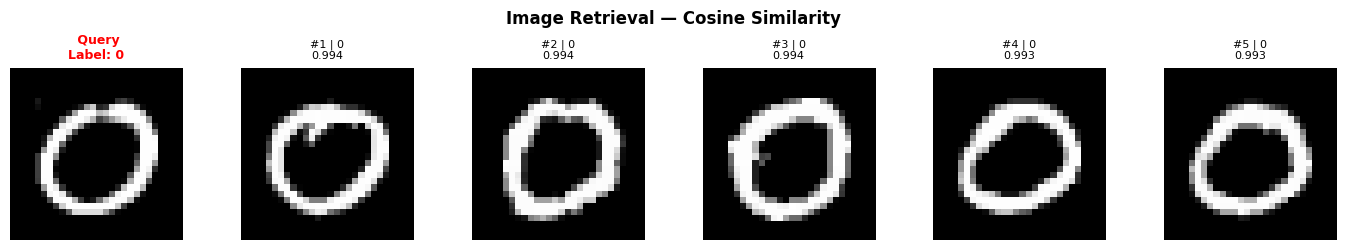

Query: 0 | Retrieved: [np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0)]


In [28]:
def retrieve_similar_images(query_idx, top_k=5):
    """تجيب أكثر top_k صور مشابهة للصورة رقم query_idx من الـ test set"""
    
    # 1) الصورة المطلوبة
    query = X_test[query_idx].reshape(1, -1)
    query_label = y_test[query_idx]
    
    # 2) نرمزها بالـ Encoder
    query_encoded = encoder.predict(query, verbose=0)  # (1, 32)
    
    # 3) Cosine Similarity مع كل الـ train set
    sims = cosine_similarity(query_encoded, X_train_encoded).flatten()  # (56000,)
    
    # 4) أعلى top_k
    top_idx = np.argsort(sims)[::-1][:top_k]
    
    # 5) نعرض النتائج
    fig, axes = plt.subplots(1, top_k+1, figsize=(14, 2.5))
    fig.suptitle('Image Retrieval — Cosine Similarity', fontsize=12, fontweight='bold')
    
    axes[0].imshow(query.reshape(28,28), cmap='gray')
    axes[0].set_title(f' Query\nLabel: {query_label}', fontsize=9, color='red', fontweight='bold')
    axes[0].axis('off')
    
    for rank, idx in enumerate(top_idx):
        axes[rank+1].imshow(X_train[idx].reshape(28,28), cmap='gray')
        axes[rank+1].set_title(f'#{rank+1} | {y_train[idx]}\n{sims[idx]:.3f}', fontsize=8)
        axes[rank+1].axis('off')
    
    plt.tight_layout()
    plt.show()
    print(f'Query: {query_label} | Retrieved: {[y_train[i] for i in top_idx]}')


# نجرب على 3 أمثلة
for test_idx in [0, 100, 200]:
    print('='*50)
    retrieve_similar_images(test_idx, top_k=5)

---

---

# Extra 

Dimensionality Reduction with t-SNE

**الخطوات:**
1. نشغّل الـ **Encoder فقط** على الـ test set → vectors بحجم 32
2. نطبق **t-SNE** لتنزيلها من 32 → 2 بُعد
3. نرسم scatter plot ملوّن بالـ label

**ليش t-SNE**
كل الخطوات الثانية تثبت الأداء بالأرقام والصور — لكن t-SNE تثبت إن الموديل فهم البيانات فعلاً


In [31]:
from sklearn.manifold import TSNE


In [34]:
X_test_encoded = encoder.predict(X_test, verbose=0)
print(f'Encoded shape: {X_test_encoded.shape}')  # (14000, 32)

# نستخدم subset عشان t-SNE بطيء على بيانات كبيرة
N = 3000
idx = np.random.choice(len(X_test_encoded), N, replace=False)

tsne_model = TSNE(max_iter=1000, random_state=42) # Use max_iter instead
X_2d  = tsne_model.fit_transform(X_test_encoded[idx])
y_sub = y_test[idx]

print(' Done!')

Encoded shape: (14000, 32)
 Done!


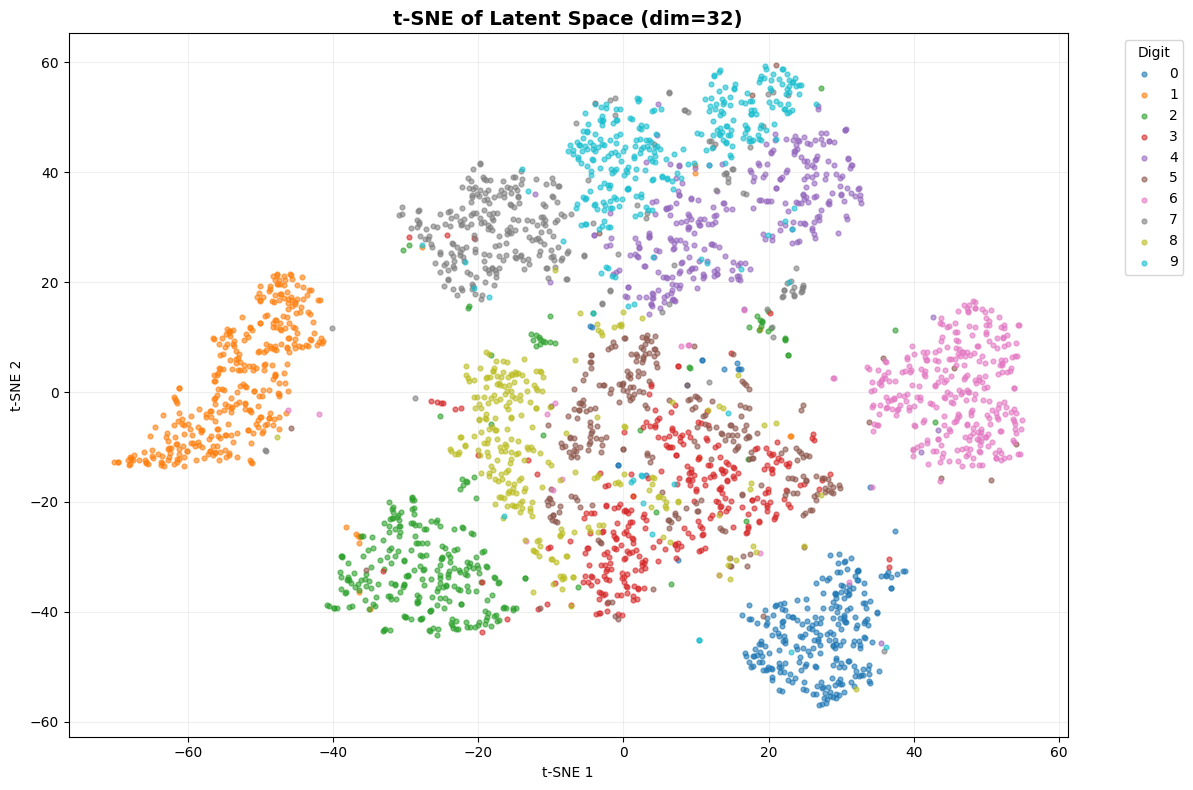

 التجمعات المنفصلة = الموديل تعلم فعلاً يميز الأرقام في الـ latent space!


In [35]:
fig, ax = plt.subplots(figsize=(12, 8))
colors = plt.cm.tab10(np.linspace(0, 1, 10))

for digit in range(10):
    mask = y_sub == digit
    ax.scatter(X_2d[mask,0], X_2d[mask,1], c=[colors[digit]],
               label=f'{digit}', alpha=0.6, s=12)

ax.set_title(f't-SNE of Latent Space (dim={LATENT_DIM})', fontsize=14, fontweight='bold')
ax.set_xlabel('t-SNE 1'); ax.set_ylabel('t-SNE 2')
ax.legend(title='Digit', bbox_to_anchor=(1.05,1), loc='upper left')
ax.grid(True, alpha=0.2)
plt.tight_layout(); plt.show()

print(' التجمعات المنفصلة = الموديل تعلم فعلاً يميز الأرقام في الـ latent space!')

طيب ليش 3و5و8 متداخله ؟

لأنها متشابهة بصرياً يعني كلها فيها منحنيات ودوائر ناقصة. الـ Autoencoder شاف هذا التشابه وخزّنهم قريبين في الـ latent space — وهذا صحيح وليس خطأ! 